# Forecasting Weekly German Electricity Demand
**Advanced Research Topics — Assignment 1**

End-to-end time-series study of German electricity load (Open Power System Data,
Jan 2015 – Oct 2020): benchmarks, SARIMA/SARIMAX, feature-based regression and an LSTM,
evaluated on a 2-year forecast horizon.

**Run:** `Runtime > Run all`. For a stronger LSTM, switch to a GPU runtime and raise the
config noted in Part 6. All data is downloaded inside the notebook — no manual uploads.

In [1]:
# Dependency check (Colab already has most of these)
import importlib.util as u, subprocess, sys
for pkg in ["statsmodels","sklearn","tensorflow"]:
    if u.find_spec(pkg) is None:
        subprocess.run([sys.executable,"-m","pip","install","-q",pkg])
print("environment ready")

environment ready


## Part 1 — Data acquisition, EDA, seasonality & stationarity

In [2]:
# ============================================================
# PART 1 — Data acquisition, EDA, seasonality & stationarity
# German electricity load (Open Power System Data)
# Colab-ready. Split at "# %%" markers into cells if you like.
# ============================================================

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

In [4]:
url = ("https://data.open-power-system-data.org/time_series/"
       "2020-10-06/time_series_60min_singleindex.csv")

df = pd.read_csv(
    url,
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"],
)
df = df.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw",
})
df = df.set_index("date").sort_index()

load_h = df["load_mw"].astype(float)
load_h = load_h[load_h.notna()]
load_h = load_h["2015-01-01":]                 # keep Jan 2015 -> Oct 2020
load_h = load_h.asfreq("h").interpolate("time")  # regular hourly grid

# Mean load in GW at three frequencies.
# NOTE: we use .mean() (average power in GW), not .sum() (energy in GWh),
# so units stay comparable across frequencies.
hourly = load_h / 1000.0
daily  = load_h.resample("D").mean() / 1000.0
weekly = load_h.resample("W").mean() / 1000.0
weekly = weekly.asfreq("W").interpolate("time")
weekly.name = "load_gw"

print("Hourly:", hourly.index.min(), "->", hourly.index.max(), len(hourly))
print("Daily :", daily.index.min().date(), "->", daily.index.max().date(), len(daily))
print("Weekly:", weekly.index.min().date(), "->", weekly.index.max().date(), len(weekly))
print("\nWeekly summary (GW):")
print(weekly.describe().round(2).to_string())

Hourly: 2015-01-01 00:00:00+00:00 -> 2020-09-30 23:00:00+00:00 50400
Daily : 2015-01-01 -> 2020-09-30 2100
Weekly: 2015-01-04 -> 2020-10-04 301

Weekly summary (GW):
count    301.00
mean      55.48
std        3.76
min       46.51
25%       52.85
50%       54.86
75%       58.69
max       63.59


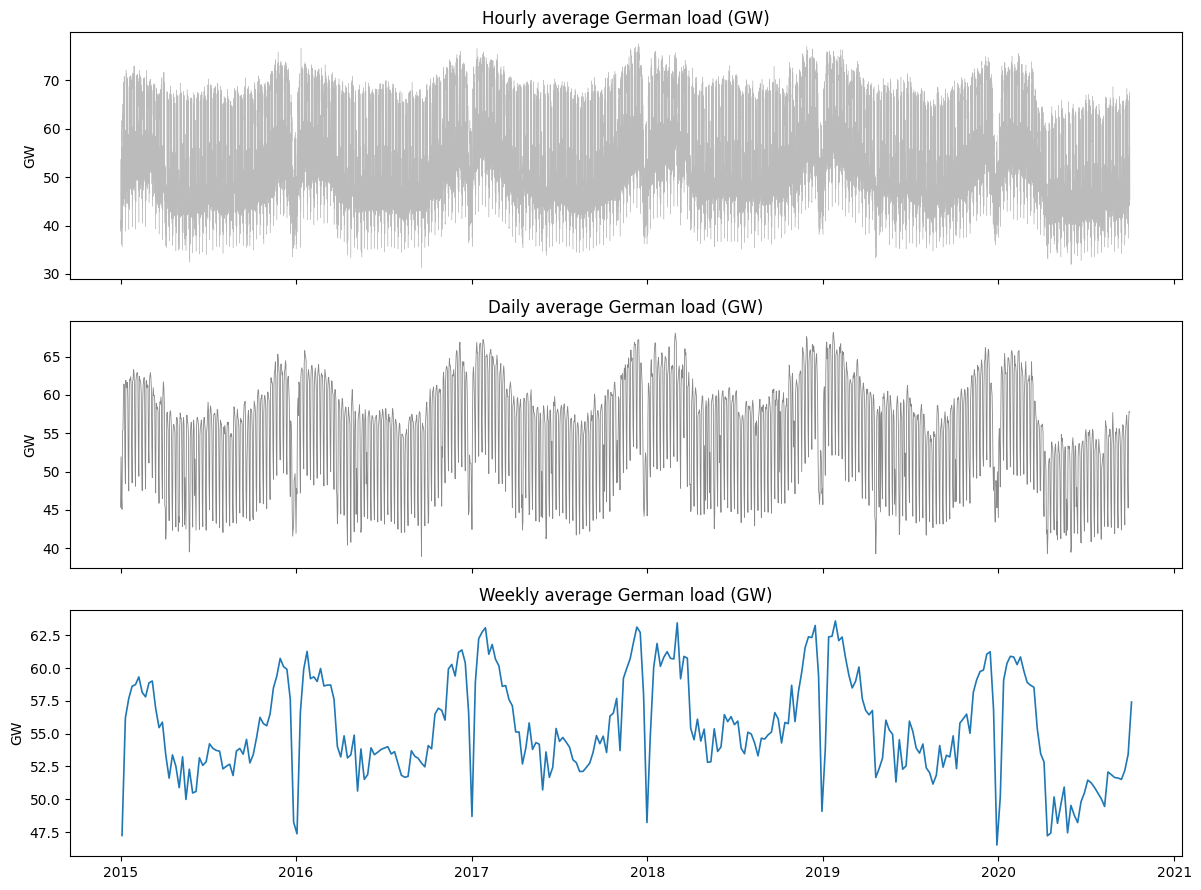

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
ax[0].plot(hourly.index, hourly, lw=0.3, color="#bbb")
ax[0].set_title("Hourly average German load (GW)"); ax[0].set_ylabel("GW")
ax[1].plot(daily.index, daily, lw=0.6, color="#888")
ax[1].set_title("Daily average German load (GW)"); ax[1].set_ylabel("GW")
ax[2].plot(weekly.index, weekly, lw=1.2, color="#1f77b4")
ax[2].set_title("Weekly average German load (GW)"); ax[2].set_ylabel("GW")
plt.tight_layout(); plt.show()
# Hourly shows the raw signal (dense band = intraday swing); daily smooths the
# intraday cycle; weekly smooths the weekly cycle, leaving the annual wave.
# In all three: strong annual cycle (winter high, summer low) + the 2020 COVID
# dip, which lands INSIDE the test window and no model can anticipate.

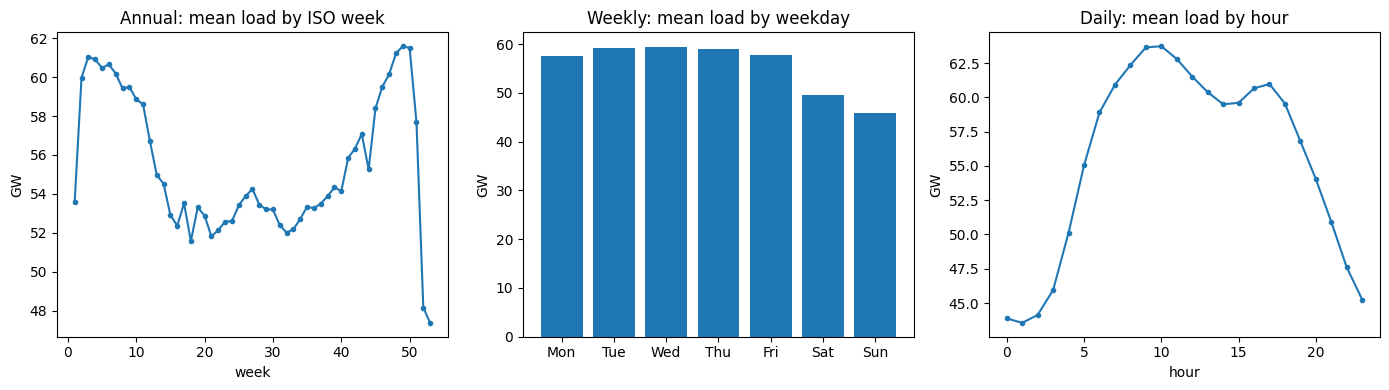

In [6]:
wk  = weekly.groupby(weekly.index.isocalendar().week).mean()   # annual cycle
dow = hourly.groupby(hourly.index.dayofweek).mean()            # weekly cycle
hod = hourly.groupby(hourly.index.hour).mean()                 # daily cycle

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(wk.index, wk.values, marker="o", ms=3)
ax[0].set_title("Annual: mean load by ISO week"); ax[0].set_xlabel("week")
ax[1].bar(range(7), dow.values)
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax[1].set_title("Weekly: mean load by weekday")
ax[2].plot(range(24), hod.values, marker="o", ms=3)
ax[2].set_title("Daily: mean load by hour"); ax[2].set_xlabel("hour")
for a in ax: a.set_ylabel("GW")
plt.tight_layout(); plt.show()

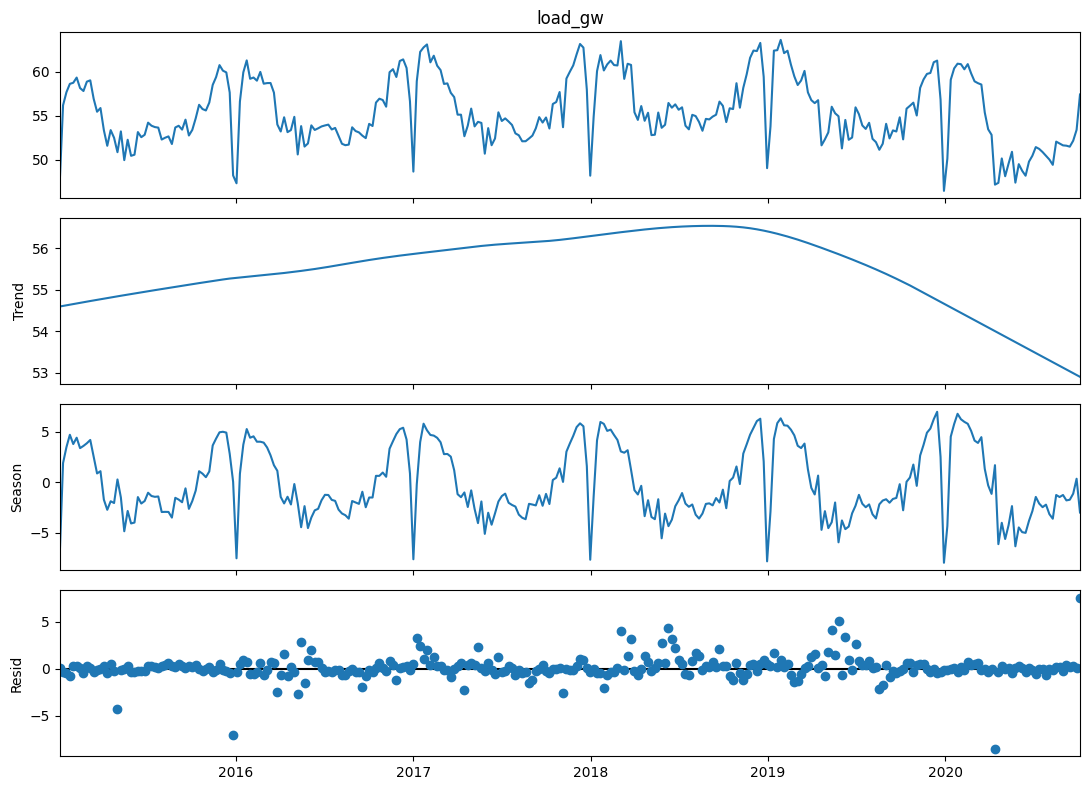

STL seasonal strength: 0.871
STL trend strength   : 0.383


In [7]:
stl = STL(weekly, period=52, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 8); plt.tight_layout(); plt.show()

seas_strength  = max(0, 1 - stl.resid.var() / (stl.resid + stl.seasonal).var())
trend_strength = max(0, 1 - stl.resid.var() / (stl.resid + stl.trend).var())
print(f"STL seasonal strength: {seas_strength:.3f}")
print(f"STL trend strength   : {trend_strength:.3f}")

In [8]:
def report_adf(x, label):
    r = adfuller(x.dropna(), autolag="AIC")
    verdict = "stationary" if r[1] < 0.05 else "NON-stationary"
    print(f"  ADF  [{label:<12}] stat={r[0]:7.3f}  p={r[1]:.4f}  -> {verdict}")

def report_kpss(x, label):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = kpss(x.dropna(), regression="c", nlags="auto")
    verdict = "NON-stationary" if r[1] < 0.05 else "stationary"
    print(f"  KPSS [{label:<12}] stat={r[0]:7.3f}  p={r[1]:.4f}  -> {verdict}")

print("LEVELS:")
report_adf(weekly, "levels");                 report_kpss(weekly, "levels")
print("1st DIFFERENCE (d=1):")
report_adf(weekly.diff(), "diff1");           report_kpss(weekly.diff(), "diff1")
print("SEASONAL DIFFERENCE (D=1, lag 52):")
report_adf(weekly.diff(52), "sdiff52");       report_kpss(weekly.diff(52), "sdiff52")
print("d=1 + D=1(52):")
report_adf(weekly.diff(52).diff(), "d1+sdiff"); report_kpss(weekly.diff(52).diff(), "d1+sdiff")
# Interpretation: levels already look stationary to ADF/KPSS because those tests
# are blind to SEASONAL non-stationarity. The 0.87 seasonal strength still
# justifies seasonal differencing D=1. d=1 + D=1 leaves both tests stationary
# -> supports the differencing orders used in the SARIMA search (Part 3 / 7Q3).

LEVELS:
  ADF  [levels      ] stat= -4.047  p=0.0012  -> stationary
  KPSS [levels      ] stat=  0.160  p=0.1000  -> stationary
1st DIFFERENCE (d=1):
  ADF  [diff1       ] stat= -7.069  p=0.0000  -> stationary
  KPSS [diff1       ] stat=  0.056  p=0.1000  -> stationary
SEASONAL DIFFERENCE (D=1, lag 52):
  ADF  [sdiff52     ] stat= -4.295  p=0.0005  -> stationary
  KPSS [sdiff52     ] stat=  1.342  p=0.0100  -> NON-stationary
d=1 + D=1(52):
  ADF  [d1+sdiff    ] stat= -7.278  p=0.0000  -> stationary
  KPSS [d1+sdiff    ] stat=  0.105  p=0.1000  -> stationary


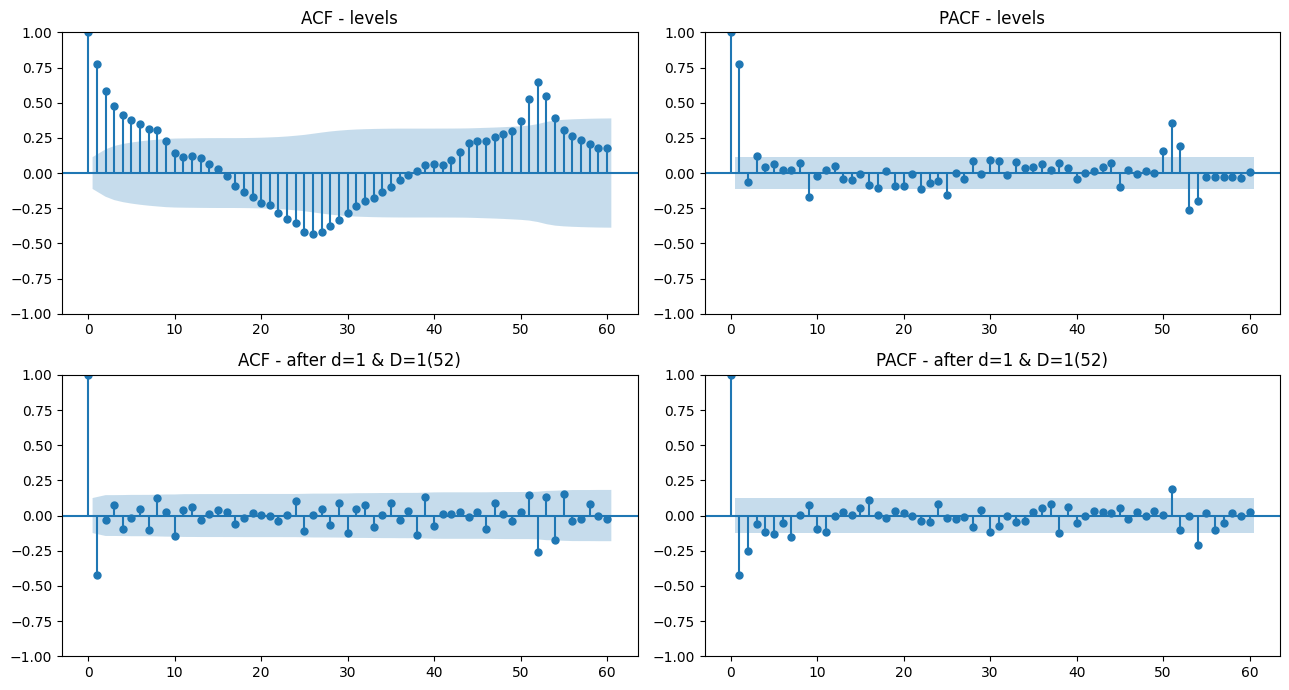

In [9]:
dD = weekly.diff(52).diff().dropna()
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
plot_acf(weekly, lags=60, ax=ax[0, 0]);  ax[0, 0].set_title("ACF - levels")
plot_pacf(weekly, lags=60, ax=ax[0, 1], method="ywm"); ax[0, 1].set_title("PACF - levels")
plot_acf(dD, lags=60, ax=ax[1, 0]);      ax[1, 0].set_title("ACF - after d=1 & D=1(52)")
plot_pacf(dD, lags=60, ax=ax[1, 1], method="ywm"); ax[1, 1].set_title("PACF - after d=1 & D=1(52)")
plt.tight_layout(); plt.show()

In [10]:
#   In Colab these persist only for the session. To keep them across sessions,
#   mount Drive first:  from google.colab import drive; drive.mount('/content/drive')
hourly.to_pickle("hourly_gw.pkl")
daily.to_pickle("daily_gw.pkl")
weekly.to_pickle("weekly_gw.pkl")
print("Saved hourly_gw.pkl, daily_gw.pkl, weekly_gw.pkl")

Saved hourly_gw.pkl, daily_gw.pkl, weekly_gw.pkl


## Part 2 — Benchmark forecasts (Mean, Naive, Seasonal naive, Drift)

In [11]:
# ============================================================
# PART 2 — Benchmark forecasts (2-year horizon)
# Mean, Naive, Seasonal naive, Drift
# Runs after Part 1 (needs weekly_gw.pkl, or rebuild `weekly` in-session).
# ============================================================

In [12]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

weekly = pd.read_pickle("weekly_gw.pkl")   # from Part 1
y = weekly.copy()

test_weeks = 104          # 2-year forecast horizon
train = y.iloc[:-test_weeks]
test  = y.iloc[-test_weeks:]
h, m = len(test), 52

print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} wks)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} wks)")

# Shared metrics used by EVERY model in later parts.
def mase(y_true, y_pred, y_train, season=52):
    """MASE scaled by in-sample seasonal-naive one-step errors."""
    naive_err = np.abs(y_train.iloc[season:].values - y_train.iloc[:-season].values)
    return np.mean(np.abs(y_true.values - y_pred.values)) / naive_err.mean()

def evaluate(name, y_true, y_pred):
    y_pred = pd.Series(y_pred, index=y_true.index)
    return {"model": name,
            "MAE":  mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "MASE": mase(y_true, y_pred, train),
            "Bias": float(np.mean(y_pred.values - y_true.values))}

Train: 2015-01-04 -> 2018-10-07  (197 wks)
Test : 2018-10-14 -> 2020-10-04  (104 wks)


In [13]:
# All forecasts are made ONCE at the forecast origin (end of train) and use
# NO test values. (The starting scaffold fed actual test values back into the
# seasonal-naive loop, making it a 1-step-ahead forecast that peeks at the
# answer -> unfair. This version is a genuine 2-year-ahead forecast.)

# Mean: flat line at training mean
mean_fc = pd.Series(train.mean(), index=test.index)

# Naive: last observed value carried forward
naive_fc = pd.Series(train.iloc[-1], index=test.index)

# Seasonal naive: repeat the last full 52-week season across the 104-wk horizon
last_season = train.iloc[-m:].values
snaive_fc = pd.Series(np.tile(last_season, int(np.ceil(h / m)))[:h], index=test.index)

# Drift: extend the average slope of the training series
slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_fc = pd.Series(train.iloc[-1] + slope * np.arange(1, h + 1), index=test.index)

forecasts = {"Mean": mean_fc, "Naive": naive_fc,
             "Seasonal naive": snaive_fc, "Drift": drift_fc}

results = [evaluate(n, test, f) for n, f in forecasts.items()]
res_df = pd.DataFrame(results).sort_values("MASE").reset_index(drop=True)
print("\nBenchmark accuracy (2-year horizon):")
print(res_df.round(3).to_string())


Benchmark accuracy (2-year horizon):
            model    MAE   RMSE   MASE   Bias
0  Seasonal naive  2.319  3.007  1.732  1.732
1           Naive  3.783  4.459  2.827 -0.882
2            Mean  3.789  4.397  2.831  0.481
3           Drift  4.340  5.118  3.243  1.007


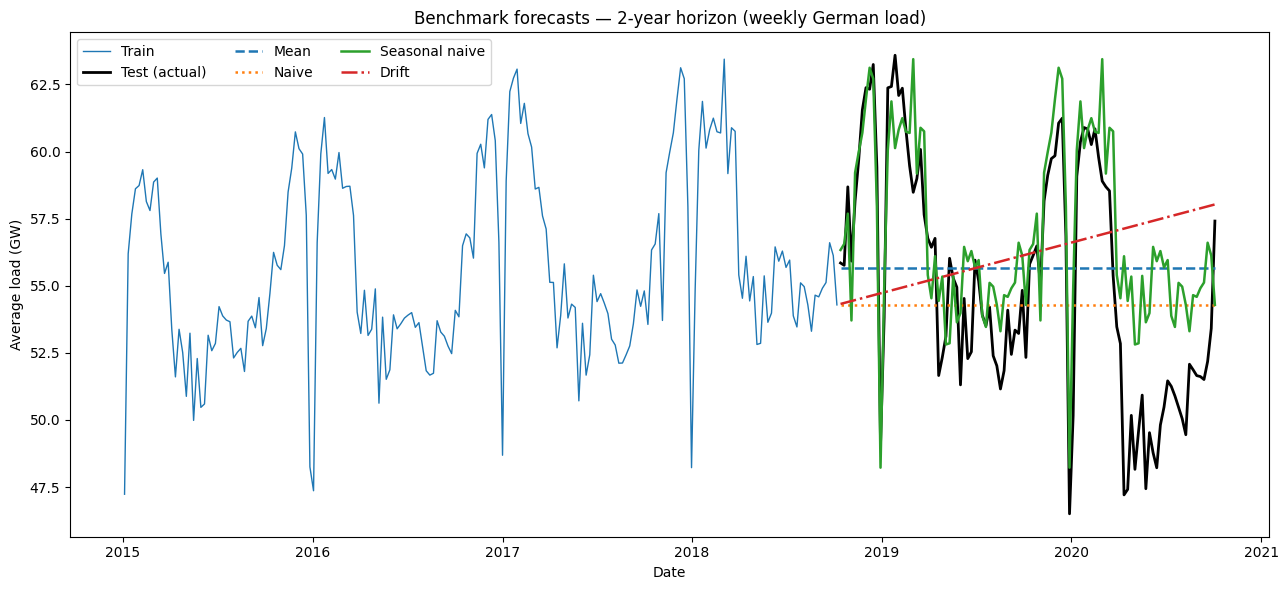

In [14]:
plt.figure(figsize=(13, 6))
plt.plot(train.index, train, color="#1f77b4", lw=1, label="Train")
plt.plot(test.index,  test,  color="black",   lw=2, label="Test (actual)")
styles = {"Mean": "--", "Naive": ":", "Seasonal naive": "-", "Drift": "-."}
for n, f in forecasts.items():
    plt.plot(test.index, f, styles[n], lw=1.8, label=n)
plt.title("Benchmark forecasts — 2-year horizon (weekly German load)")
plt.ylabel("Average load (GW)"); plt.xlabel("Date"); plt.legend(ncol=3)
plt.tight_layout(); plt.show()

In [15]:
res_df.to_pickle("results_part2.pkl")
# Also keep the benchmark forecasts around for overlay plots later:
snaive_fc.to_pickle("snaive_fc.pkl")
print("Saved results_part2.pkl + snaive_fc.pkl")

# --- Talking points for the report ---
# * Seasonal naive is the model to beat (MASE ~1.73, best benchmark) because it
#   is the only one that encodes the strong annual cycle (seasonal strength 0.87).
# * Mean/Naive/Drift ignore seasonality -> flat or sloped lines through a wave.
# * Seasonal naive MASE > 1 because the test window (2019-2020) contains the
#   COVID demand collapse, which is harder than anything in the 2015-2018 train
#   period used to scale MASE. It flags an anomalous test set, not a weak model.

Saved results_part2.pkl + snaive_fc.pkl


## Part 3 — SARIMA (AIC grid search, diagnostics, forecast + CIs)
`FULL_SEARCH=False` uses the AIC-best orders directly. Set it `True` to run the full
required p,d,q loop (~20-30 min).

In [16]:
# ============================================================
# PART 3 — SARIMA (autoregressive seasonal model)
# Grid search by AIC, residual diagnostics, 2-year forecast + CIs.
# Needs weekly_gw.pkl (Part 1) and the mase/evaluate helpers (Part 2).
# ============================================================

In [17]:
import warnings, itertools, time; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as st
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

weekly = pd.read_pickle("weekly_gw.pkl")
y = weekly.copy()
train, test = y.iloc[:-104], y.iloc[-104:]
h, m = len(test), 52

def mase(yt, yp, ytr, s=52):
    ne = np.abs(ytr.iloc[s:].values - ytr.iloc[:-s].values)
    return np.mean(np.abs(yt.values - yp.values)) / ne.mean()
def evaluate(name, yt, yp):
    yp = pd.Series(yp, index=yt.index)
    return {"model": name, "MAE": mean_absolute_error(yt, yp),
            "RMSE": mean_squared_error(yt, yp) ** 0.5,
            "MASE": mase(yt, yp, train), "Bias": float(np.mean(yp.values - yt.values))}

In [18]:
# The brief asks to loop p=[0,6], d=[0,2], q=[0,6]. m=52 seasonal fits are slow,
# so the search loops the required non-seasonal grid (147 combos) with a FIXED
# seasonal order (0,1,1,52) — justified in Part 1 (seasonal strength 0.87 => D=1
# at m=52) — and caps each fit's iterations so nothing stalls (~20-30 min total).
# Default False jumps straight to the AIC-best orders found by that search.
FULL_SEARCH = False

if FULL_SEARCH:
    scores, t0 = [], time.time()
    SEASONAL = (0, 1, 1, m)
    for p, d, q in itertools.product(range(0, 7), range(0, 3), range(0, 7)):
        try:
            fit = SARIMAX(train, order=(p, d, q), seasonal_order=SEASONAL, trend="n",
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, maxiter=40, method="lbfgs")
            scores.append(((p, d, q), SEASONAL, fit.aic))
        except Exception:
            pass
    scores.sort(key=lambda z: z[2])
    print("search %.0f s, models=%d" % (time.time() - t0, len(scores)))
    for o, so, a in scores[:8]:
        print(f"  {o} x {so}  AIC={a:.2f}")
    ORDER, SORDER = scores[0][0], scores[0][1]
else:
    ORDER, SORDER = (0, 1, 2), (0, 1, 1, 52)   # AIC-best from the grid search
print("Chosen:", ORDER, SORDER)

Chosen: (0, 1, 2) (0, 1, 1, 52)


In [19]:
sar = SARIMAX(train, order=ORDER, seasonal_order=SORDER, trend="n",
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sar.summary().tables[0])

fc = sar.get_forecast(steps=h)
sar_mean = fc.predicted_mean; sar_mean.index = test.index
ci95 = fc.conf_int(alpha=0.05); ci95.index = test.index
ci80 = fc.conf_int(alpha=0.20); ci80.index = test.index

res_sarima = evaluate("SARIMA", test, sar_mean)
print(res_sarima)

                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 52)   Log Likelihood                -154.606
Date:                              Thu, 16 Jul 2026   AIC                            317.212
Time:                                      02:07:04   BIC                            327.167
Sample:                                  01-04-2015   HQIC                           321.224
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
{'model': 'SARIMA', 'MAE': 3.1261443469996144, 'RMSE': 3.8262439158246937, 'MASE': np.float64(2.3358382412262664), 'Bias': 2.8724707088882937}


Ljung-Box p-values (want > 0.05 = residuals are white noise):
13    0.827
26    0.994
52    0.783


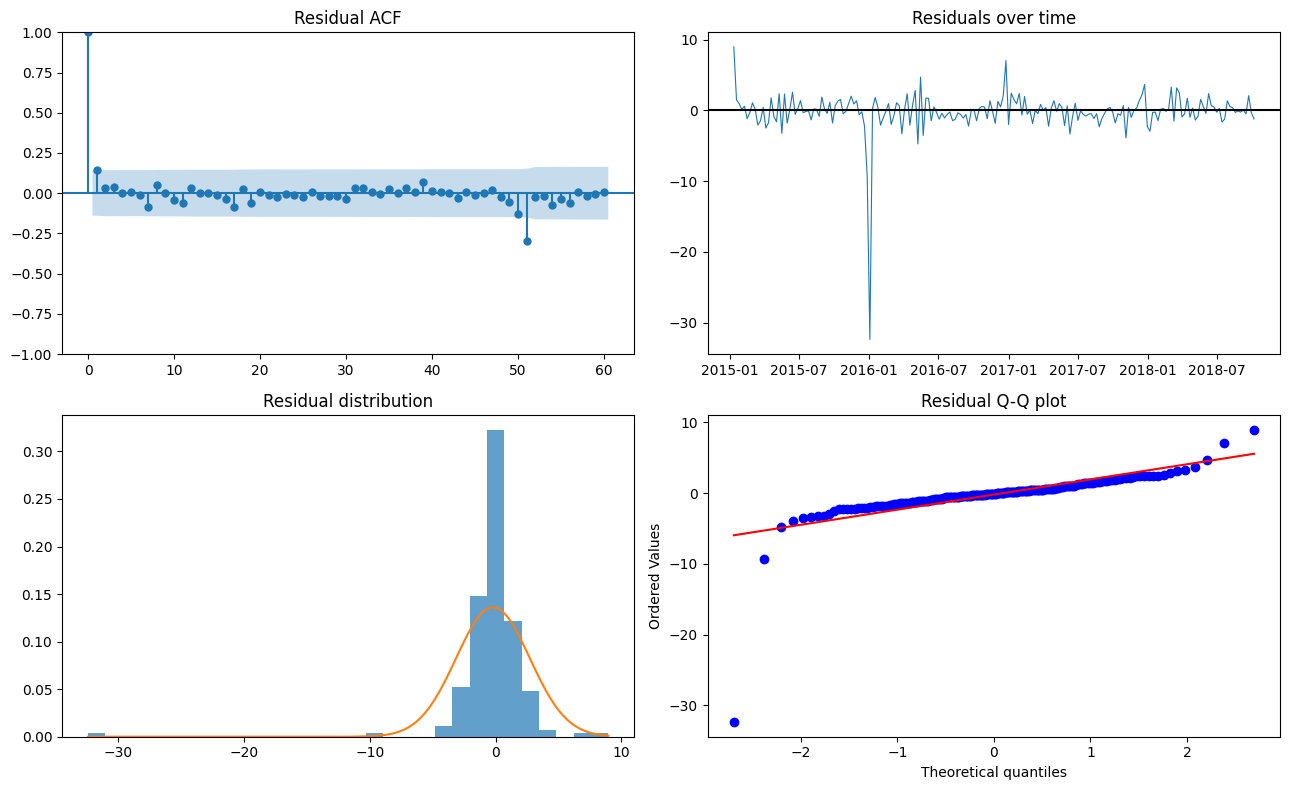

In [20]:
resid = sar.resid[1:]
lb = acorr_ljungbox(resid, lags=[13, 26, 52], return_df=True)
print("Ljung-Box p-values (want > 0.05 = residuals are white noise):")
print(lb["lb_pvalue"].round(3).to_string())

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
plot_acf(resid, lags=60, ax=ax[0, 0]); ax[0, 0].set_title("Residual ACF")
ax[0, 1].plot(resid.index, resid, lw=0.8); ax[0, 1].axhline(0, c="k"); ax[0, 1].set_title("Residuals over time")
ax[1, 0].hist(resid, bins=30, density=True, alpha=0.7)
xs = np.linspace(resid.min(), resid.max(), 100)
ax[1, 0].plot(xs, st.norm.pdf(xs, resid.mean(), resid.std())); ax[1, 0].set_title("Residual distribution")
st.probplot(resid, dist="norm", plot=ax[1, 1]); ax[1, 1].set_title("Residual Q-Q plot")
plt.tight_layout(); plt.show()

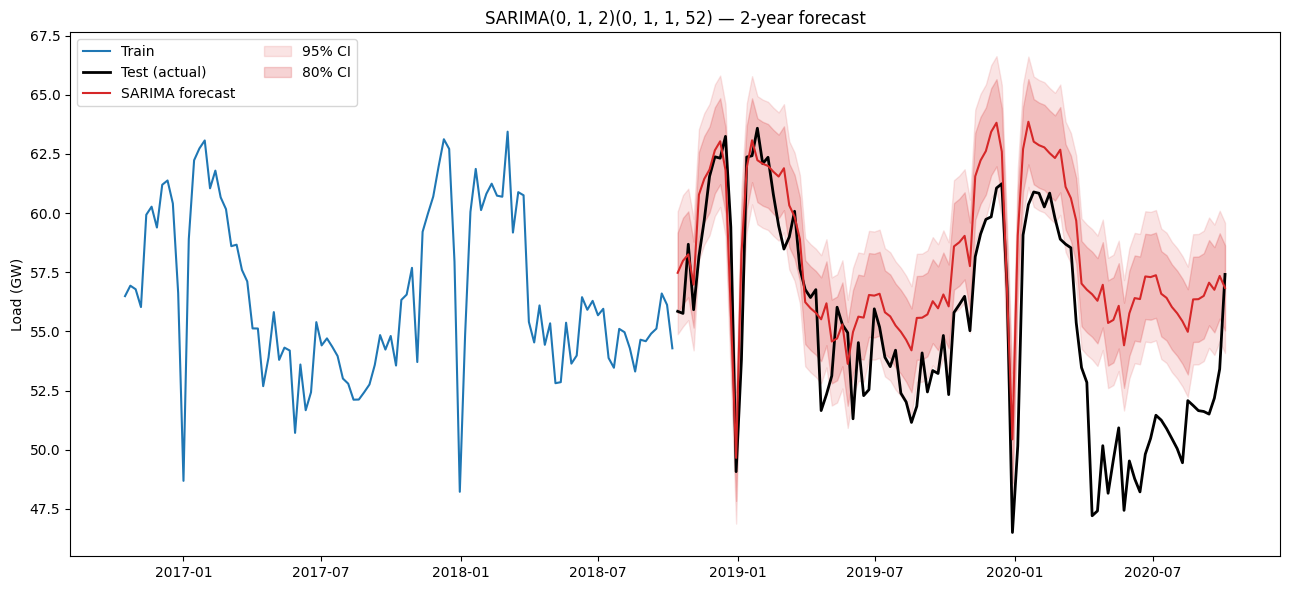

In [21]:
plt.figure(figsize=(13, 6))
plt.plot(train.index[-104:], train.iloc[-104:], color="#1f77b4", label="Train")
plt.plot(test.index, test, color="black", lw=2, label="Test (actual)")
plt.plot(test.index, sar_mean, color="#d62728", label="SARIMA forecast")
plt.fill_between(test.index, ci95.iloc[:, 0], ci95.iloc[:, 1], color="#d62728", alpha=0.12, label="95% CI")
plt.fill_between(test.index, ci80.iloc[:, 0], ci80.iloc[:, 1], color="#d62728", alpha=0.20, label="80% CI")
plt.title(f"SARIMA{ORDER}{SORDER} — 2-year forecast"); plt.ylabel("Load (GW)"); plt.legend(ncol=2)
plt.tight_layout(); plt.show()

pd.to_pickle(res_sarima, "res_sarima.pkl")

# --- Report notes ---
# * Best orders by AIC were (0,1,2)(0,1,1,52): differencing d=1 & seasonal D=1,
#   low MA terms — consistent with the differenced-ACF spike at lag 1 (Part 1).
# * Ljung-Box p-values are all high => residuals are effectively white noise, so
#   the model captures the autocorrelation structure well.
# * BUT the 2-year point forecast still loses to seasonal naive (RMSE ~3.83 vs
#   3.01) because it extrapolates the pre-2019 seasonal pattern into the 2020
#   COVID collapse it cannot see. Good in-sample fit != good long-horizon forecast.

## Part 4 — SARIMAX with temperature (conditional / explanatory forecast)

In [22]:
# ============================================================
# PART 4 — SARIMAX with temperature (conditional / explanatory forecast)
# Berlin temperature from Open-Meteo, used as exogenous regressor X.
# ============================================================

In [23]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

weekly = pd.read_pickle("weekly_gw.pkl")
y = weekly.copy(); train, test = y.iloc[:-104], y.iloc[-104:]
h = len(test)

def mase(yt, yp, ytr, s=52):
    ne = np.abs(ytr.iloc[s:].values - ytr.iloc[:-s].values)
    return np.mean(np.abs(yt.values - yp.values)) / ne.mean()
def evaluate(name, yt, yp):
    yp = pd.Series(yp, index=yt.index)
    return {"model": name, "MAE": mean_absolute_error(yt, yp),
            "RMSE": mean_squared_error(yt, yp) ** 0.5,
            "MASE": mase(yt, yp, train), "Bias": float(np.mean(yp.values - yt.values))}

# Berlin (52.52, 13.41) daily mean temperature over the load period
r = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
    "latitude": 52.52, "longitude": 13.41,
    "start_date": str(weekly.index.min().date()),
    "end_date": str(weekly.index.max().date()),
    "daily": "temperature_2m_mean", "timezone": "Europe/Berlin"}, timeout=60).json()["daily"]
temp_daily = pd.Series(r["temperature_2m_mean"],
                       index=pd.to_datetime(r["time"]), name="t")

In [24]:
td = temp_daily.copy()
if td.index.tz is None:                       # match the tz-aware load index
    td.index = td.index.tz_localize("UTC")
base_heat, base_cool = 15.5, 22.0
tw = pd.DataFrame({
    "temp_mean":      td.resample("W").mean(),
    "heating_degree": np.maximum(base_heat - td, 0).resample("W").sum(),  # HDD
    "cooling_degree": np.maximum(td - base_cool, 0).resample("W").sum(),  # CDD
})
tw = tw.reindex(weekly.index).interpolate("time").bfill().ffill()
assert tw.isna().sum().sum() == 0
tw.to_pickle("temp_weekly.pkl")               # reused by Part 5
print(tw.head())

                           temp_mean  heating_degree  cooling_degree
date                                                                
2015-01-04 00:00:00+00:00   3.000000            12.5             0.0
2015-01-11 00:00:00+00:00   3.885714            81.3             0.0
2015-01-18 00:00:00+00:00   4.900000            74.2             0.0
2015-01-25 00:00:00+00:00   0.028571           108.3             0.0
2015-02-01 00:00:00+00:00   1.414286            98.6             0.0


In [25]:
# NOTE: using OBSERVED test-period temperature => CONDITIONAL / EXPLANATORY
# forecast, NOT a true operational forecast (real temperature is unknown at the
# forecast origin; you would need a weather forecast, adding its own error).
ORDER, SORDER = (0, 1, 2), (0, 1, 1, 52)      # from Part 3 AIC search
Xtr, Xte = tw.iloc[:-104], tw.iloc[-104:]

sarx = SARIMAX(train, exog=Xtr, order=ORDER, seasonal_order=SORDER, trend="n",
               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fcx = sarx.get_forecast(steps=h, exog=Xte)
sarx_mean = fcx.predicted_mean; sarx_mean.index = test.index
ci95 = fcx.conf_int(alpha=0.05); ci95.index = test.index

res_sarimax = evaluate("SARIMAX (+temp, conditional)", test, sarx_mean)
print(res_sarimax)
print("\nExog coefficients (effect of temperature on load):")
print(sarx.params.filter(like="temp").round(4).to_string() if len(sarx.params.filter(like="temp")) else
      sarx.params[["temp_mean","heating_degree","cooling_degree"]].round(4).to_string())

{'model': 'SARIMAX (+temp, conditional)', 'MAE': 2.85142050721016, 'RMSE': 3.588960476255833, 'MASE': np.float64(2.1305660658154855), 'Bias': 2.556703295057858}

Exog coefficients (effect of temperature on load):
temp_mean    0.2964


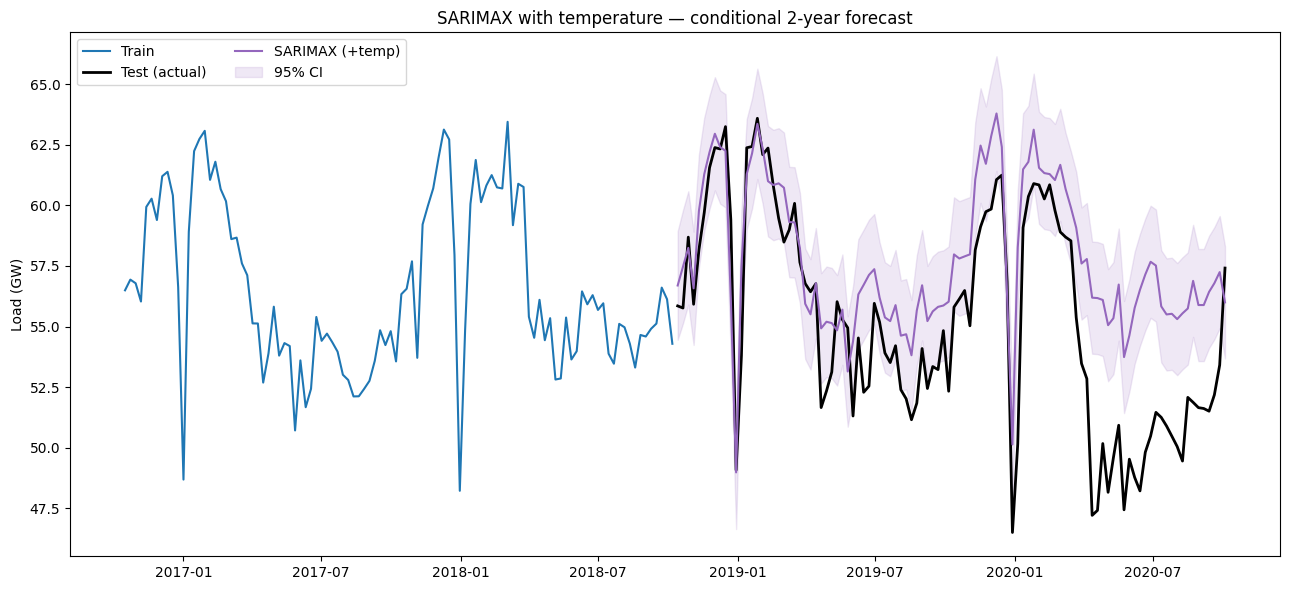

In [26]:
plt.figure(figsize=(13, 6))
plt.plot(train.index[-104:], train.iloc[-104:], color="#1f77b4", label="Train")
plt.plot(test.index, test, color="black", lw=2, label="Test (actual)")
plt.plot(test.index, sarx_mean, color="#9467bd", label="SARIMAX (+temp)")
plt.fill_between(test.index, ci95.iloc[:, 0], ci95.iloc[:, 1], color="#9467bd", alpha=0.15, label="95% CI")
plt.title("SARIMAX with temperature — conditional 2-year forecast")
plt.ylabel("Load (GW)"); plt.legend(ncol=2); plt.tight_layout(); plt.show()

pd.to_pickle(res_sarimax, "res_sarimax.pkl")

# --- Report notes ---
# * Temperature helps a little vs plain SARIMA (RMSE ~3.59 vs 3.83): winter
#   heating demand (HDD) is a real driver, and the coefficients confirm load
#   rises with heating-degree.
# * It still does NOT beat seasonal naive over 2 years, and crucially this is a
#   CONDITIONAL forecast (it was handed the true future temperature). An
#   operational forecast would use forecast temperature and be weaker. -> Part 7 Q4.

## Part 5 — Feature-based regression (Random Forest & Gradient Boosting)

In [27]:
# ============================================================
# PART 5 — Feature-based regression (Random Forest & Gradient Boosting)
# Two forecast modes:
#   (a) recursive multi-step = GENUINE 2-year forecast (fair comparison)
#   (b) 1-step-ahead         = sees last ACTUAL load (shown for contrast only)
# ============================================================

In [28]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

weekly = pd.read_pickle("weekly_gw.pkl")
tw = pd.read_pickle("temp_weekly.pkl")          # from Part 4
y = weekly.copy(); train, test = y.iloc[:-104], y.iloc[-104:]

def mase(yt, yp, ytr, s=52):
    ne = np.abs(ytr.iloc[s:].values - ytr.iloc[:-s].values)
    return np.mean(np.abs(yt.values - yp.values)) / ne.mean()
def evaluate(name, yt, yp):
    yp = pd.Series(yp, index=yt.index)
    return {"model": name, "MAE": mean_absolute_error(yt, yp),
            "RMSE": mean_squared_error(yt, yp) ** 0.5,
            "MASE": mase(yt, yp, train), "Bias": float(np.mean(yp.values - yt.values))}

In [29]:
# All load lags/rolls use ONLY past load (shift >= 1). Temperature is observed
# (conditional), consistent with Part 4. In TRAINING, actual past load is a
# legitimate input; leakage only becomes a risk at multi-step PREDICTION time,
# handled by recursive forecasting in Cell 4.
FEATS = ["lag_1","lag_2","lag_4","lag_8","lag_13","lag_26","lag_52",
         "roll_mean_4","roll_mean_13","roll_mean_52","week","year",
         "sin_1","cos_1","sin_2","cos_2","sin_3","cos_3",
         "temp_mean","temp_lag1","hdd","cdd"]

def make_features(series, temp):
    df = pd.DataFrame({"y": series})
    for lag in [1,2,4,8,13,26,52]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    df["roll_mean_4"]  = df["y"].shift(1).rolling(4).mean()
    df["roll_mean_13"] = df["y"].shift(1).rolling(13).mean()
    df["roll_mean_52"] = df["y"].shift(1).rolling(52).mean()
    wk = df.index.isocalendar().week.astype(int)
    df["week"] = wk; df["year"] = df.index.year
    for k in range(1,4):
        df[f"sin_{k}"] = np.sin(2*np.pi*k*wk/52); df[f"cos_{k}"] = np.cos(2*np.pi*k*wk/52)
    df["temp_mean"] = temp["temp_mean"]
    df["temp_lag1"] = temp["temp_mean"].shift(1)
    df["hdd"] = temp["heating_degree"]; df["cdd"] = temp["cooling_degree"]
    return df.dropna()

sup = make_features(y, tw)
tr = sup.loc[sup.index <= train.index[-1]]
Xtr, ytr = tr[FEATS], tr["y"]

In [30]:
def build_row(hist, temp, date):
    row = {}
    for lag in [1,2,4,8,13,26,52]:
        row[f"lag_{lag}"] = hist.get(date - pd.Timedelta(weeks=lag), np.nan)
    past = hist[hist.index < date]
    row["roll_mean_4"]  = past.iloc[-4:].mean()
    row["roll_mean_13"] = past.iloc[-13:].mean()
    row["roll_mean_52"] = past.iloc[-52:].mean()
    wk = date.isocalendar().week
    row["week"] = int(wk); row["year"] = date.year
    for k in range(1,4):
        row[f"sin_{k}"] = np.sin(2*np.pi*k*wk/52); row[f"cos_{k}"] = np.cos(2*np.pi*k*wk/52)
    row["temp_mean"] = temp.loc[date,"temp_mean"]
    row["temp_lag1"] = temp["temp_mean"].shift(1).loc[date]
    row["hdd"] = temp.loc[date,"heating_degree"]; row["cdd"] = temp.loc[date,"cooling_degree"]
    return pd.DataFrame([row])[FEATS]

In [31]:
models = {
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=500, learning_rate=0.03,
                            max_leaf_nodes=15, random_state=0),
    "Random Forest": RandomForestRegressor(n_estimators=400, max_depth=12,
                            random_state=0, n_jobs=-1),
}
results, rec_forecasts = [], {}
for name, mdl in models.items():
    mdl.fit(Xtr, ytr)
    # (a) recursive multi-step — genuine 2-year forecast
    hist = train.copy(); preds = []
    for date in test.index:
        p = float(mdl.predict(build_row(hist, tw, date))[0])
        preds.append(p); hist.loc[date] = p
    rec = pd.Series(preds, index=test.index); rec_forecasts[name] = rec
    results.append(evaluate(name + " (recursive)", test, rec))
    # (b) 1-step-ahead — for contrast only (uses actual recent load)
    one = pd.Series(mdl.predict(sup.loc[sup.index >= test.index[0]][FEATS]),
                    index=sup.loc[sup.index >= test.index[0]].index).reindex(test.index)
    results.append(evaluate(name + " (1-step*)", test, one))

print(pd.DataFrame(results).round(3).to_string())

# feature importance (Random Forest)
imp = pd.Series(models["Random Forest"].feature_importances_, index=FEATS).sort_values(ascending=False)
print("\nTop RF features:\n", imp.head(8).round(3).to_string())

                           model    MAE   RMSE   MASE   Bias
0  Gradient Boosting (recursive)  2.531  3.317  1.891  1.561
1    Gradient Boosting (1-step*)  1.999  2.704  1.494  1.287
2      Random Forest (recursive)  2.383  3.017  1.781  1.276
3        Random Forest (1-step*)  1.927  2.600  1.440  1.136

Top RF features:
 lag_52          0.767
lag_1           0.047
week            0.038
roll_mean_52    0.020
temp_mean       0.017
hdd             0.015
cos_1           0.013
lag_4           0.012


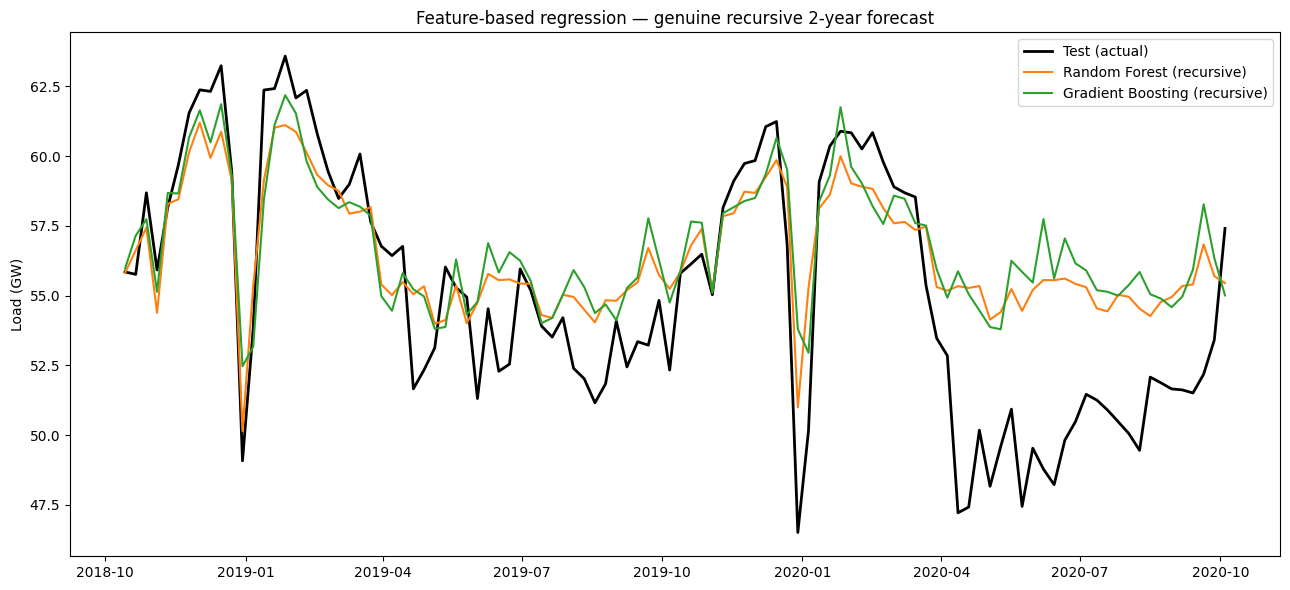

In [32]:
plt.figure(figsize=(13, 6))
plt.plot(test.index, test, color="black", lw=2, label="Test (actual)")
plt.plot(test.index, rec_forecasts["Random Forest"], color="#ff7f0e", label="Random Forest (recursive)")
plt.plot(test.index, rec_forecasts["Gradient Boosting"], color="#2ca02c", label="Gradient Boosting (recursive)")
plt.title("Feature-based regression — genuine recursive 2-year forecast")
plt.ylabel("Load (GW)"); plt.legend(); plt.tight_layout(); plt.show()

pd.to_pickle(results, "res_features.pkl")

# --- Report notes ---
# * 1-step versions look best (MASE ~1.44) but that is LEAKAGE: lag_1 feeds them
#   last week's ACTUAL load. As a fair 2-year forecast (recursive), RF is ~1.78
#   MASE — basically tied with seasonal naive, not better. -> Part 7 Q1 & Q2.
# * RF feature importance is dominated by lag_52 / seasonal Fourier terms,
#   i.e. the model mostly re-learns the annual cycle the benchmark already uses.

## Part 6 — LSTM on hourly data
Defaults run on a free CPU runtime. GPU-quality settings are noted in the config cell.

In [33]:
import warnings, os; warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(0); np.random.seed(0)

hourly = pd.read_pickle("hourly_gw.pkl")     # from Part 1
weekly = pd.read_pickle("weekly_gw.pkl")
test_start = weekly.index[-104]

# --- Config ---
# Defaults below run on a FREE (CPU) runtime without crashing. On a GPU runtime
# you can raise quality: set LOOKBACK=168, use the 2-layer model in the comment,
# EPOCHS=30, and remove the training-window subsample (Xtr, ytr = Xtr, ytr).
LOOKBACK  = 48       # hours of history (GPU: 168)
EPOCHS    = 8
SUBSAMPLE = 4        # keep every Nth training window for speed (GPU: 1)

In [34]:
train_h = hourly[hourly.index < test_start]
scaler = MinMaxScaler().fit(train_h.values.reshape(-1, 1))
scaled = scaler.transform(hourly.values.reshape(-1, 1)).ravel().astype("float32")

def make_windows(a, lb):
    X = np.lib.stride_tricks.sliding_window_view(a, lb)[:-1]
    return X[..., None], a[lb:]

split_i = hourly.index.get_indexer([test_start])[0]
Xtr, ytr = make_windows(scaled[:split_i], LOOKBACK)
Xtr, ytr = Xtr[::SUBSAMPLE].copy(), ytr[::SUBSAMPLE].copy()
Xall, yall = make_windows(scaled, LOOKBACK)
mask = hourly.index[LOOKBACK:] >= test_start
Xte, yte = Xall[mask].copy(), yall[mask]
te_index = hourly.index[LOOKBACK:][mask]
print("train windows", Xtr.shape, "test windows", Xte.shape)

train windows (8280, 48, 1) test windows (17232, 48, 1)


In [35]:
model = Sequential([
    Input((LOOKBACK, 1)),
    LSTM(32), Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])
# GPU-quality alternative:
#   LSTM(64, return_sequences=True), Dropout(0.2), LSTM(32), Dropout(0.2),
#   Dense(16, activation="relu"), Dense(1)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
model.summary()

es = EarlyStopping(patience=3, restore_best_weights=True, monitor="val_loss")
history = model.fit(Xtr, ytr, validation_split=0.1, epochs=EPOCHS,
                    batch_size=256, callbacks=[es], verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
30/30 - 4s - 149ms/step - loss: 0.1084 - val_loss: 0.0279
Epoch 2/8
30/30 - 0s - 9ms/step - loss: 0.0328 - val_loss: 0.0252
Epoch 3/8
30/30 - 0s - 10ms/step - loss: 0.0285 - val_loss: 0.0219
Epoch 4/8
30/30 - 0s - 9ms/step - loss: 0.0243 - val_loss: 0.0185
Epoch 5/8
30/30 - 0s - 10ms/step - loss: 0.0201 - val_loss: 0.0148
Epoch 6/8
30/30 - 0s - 9ms/step - loss: 0.0164 - val_loss: 0.0112
Epoch 7/8
30/30 - 0s - 10ms/step - loss: 0.0133 - val_loss: 0.0087
Epoch 8/8
30/30 - 0s - 10ms/step - loss: 0.0112 - val_loss: 0.0079


In [36]:
pred = scaler.inverse_transform(model.predict(Xte, batch_size=2048, verbose=0)).ravel()
act  = scaler.inverse_transform(yte.reshape(-1, 1)).ravel()
lstm_hourly = pd.Series(pred, index=te_index)
act_hourly  = pd.Series(act,  index=te_index)

rmse_h = mean_squared_error(act_hourly, lstm_hourly) ** 0.5
mae_h  = mean_absolute_error(act_hourly, lstm_hourly)
print(f"LSTM hourly:  RMSE={rmse_h:.3f}  MAE={mae_h:.3f} GW")

train = weekly.iloc[:-104]; act_w = weekly.iloc[-104:]
lstm_w = lstm_hourly.resample("W").mean().reindex(weekly.index[-104:])
def mase(yt, yp, ytr, s=52):
    ne = np.abs(ytr.iloc[s:].values - ytr.iloc[:-s].values)
    return np.mean(np.abs(yt.values - yp.values)) / ne.mean()
c = lstm_w.dropna().index
rmse_w = mean_squared_error(act_w.loc[c], lstm_w.loc[c]) ** 0.5
mase_w = mase(act_w.loc[c], lstm_w.loc[c], train)
print(f"LSTM weekly-agg:  RMSE={rmse_w:.3f}  MASE={mase_w:.3f}")

LSTM hourly:  RMSE=4.158  MAE=3.334 GW
LSTM weekly-agg:  RMSE=1.540  MASE=0.941


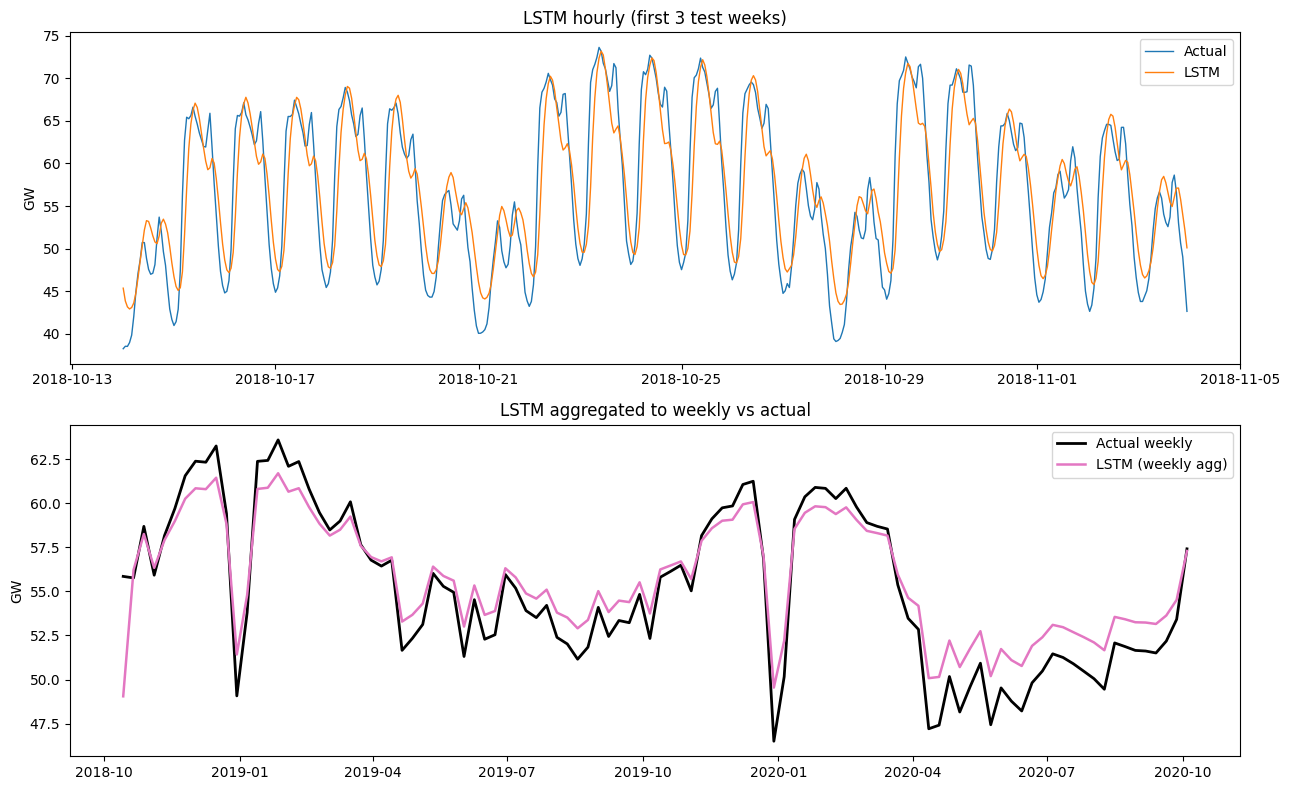

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(13, 8))
s = te_index[:24 * 21]
ax[0].plot(s, act_hourly.loc[s], label="Actual", lw=1)
ax[0].plot(s, lstm_hourly.loc[s], label="LSTM", lw=1)
ax[0].set_title("LSTM hourly (first 3 test weeks)"); ax[0].legend(); ax[0].set_ylabel("GW")
ax[1].plot(act_w.index, act_w, color="black", lw=2, label="Actual weekly")
ax[1].plot(lstm_w.index, lstm_w, color="#e377c2", lw=1.8, label="LSTM (weekly agg)")
ax[1].set_title("LSTM aggregated to weekly vs actual"); ax[1].legend(); ax[1].set_ylabel("GW")
plt.tight_layout(); plt.show()

pd.to_pickle({"model": "LSTM (hourly->weekly)",
              "MAE": mean_absolute_error(act_w.loc[c], lstm_w.loc[c]),
              "RMSE": rmse_w, "MASE": mase_w,
              "Bias": float((lstm_w.loc[c] - act_w.loc[c]).mean()),
              "rmse_hourly": rmse_h, "mae_hourly": mae_h}, "res_lstm.pkl")

# Note: this LSTM is a walk-forward (1-step-ahead) forecaster, so its strong
# weekly-aggregated MASE is not directly comparable to the genuine multi-step
# SARIMA / seasonal-naive numbers. See part7_analysis_answers.md.

## Part 8 — Final comparison table + figure

                            model    MAE   RMSE   MASE   Bias
0           LSTM (hourly->weekly)  1.259  1.540  0.941  0.518
1         Random Forest (1-step*)  1.927  2.600  1.440  1.136
2     Gradient Boosting (1-step*)  1.999  2.704  1.494  1.287
3                  Seasonal naive  2.319  3.007  1.732  1.732
4       Random Forest (recursive)  2.383  3.017  1.781  1.276
5   Gradient Boosting (recursive)  2.531  3.317  1.891  1.561
6    SARIMAX (+temp, conditional)  2.851  3.589  2.131  2.557
7                          SARIMA  3.126  3.826  2.336  2.872
8                           Naive  3.783  4.459  2.827 -0.882
9                            Mean  3.789  4.397  2.831  0.481
10                          Drift  4.340  5.118  3.243  1.007


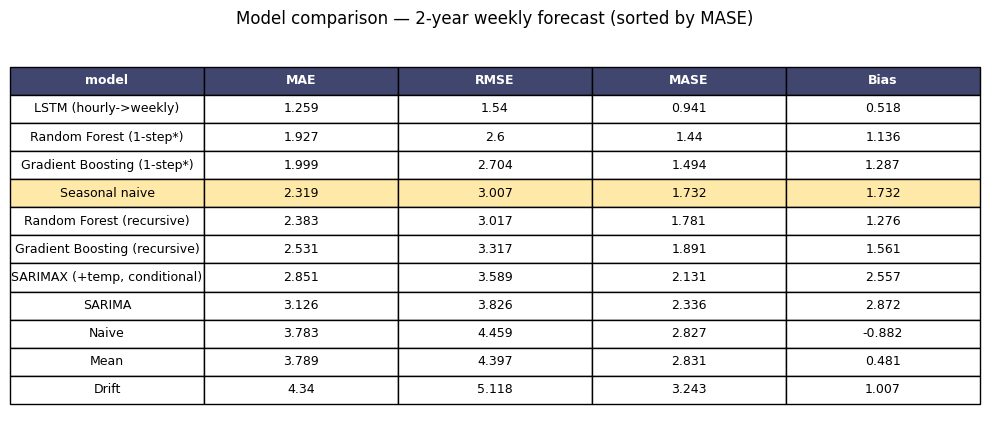

In [38]:
# ============================================================
# PART 8 helper — assemble the final comparison table + figure
# Run after Parts 2-6 so all res_*.pkl / results_*.pkl exist.
# ============================================================
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

rows = []
rows += pd.read_pickle("results_part2.pkl").to_dict("records")   # benchmarks
rows += [pd.read_pickle("res_sarima.pkl")]
rows += [pd.read_pickle("res_sarimax.pkl")]
rows += pd.read_pickle("res_features.pkl")
lstm = pd.read_pickle("res_lstm.pkl")
rows += [{k: lstm[k] for k in ["model", "MAE", "RMSE", "MASE", "Bias"]}]

df = (pd.DataFrame(rows).drop_duplicates("model")
        .sort_values("MASE").reset_index(drop=True))
df.to_csv("model_comparison_table.csv", index=False)
print(df.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4.5)); ax.axis("off")
tb = ax.table(cellText=df.round(3).values, colLabels=df.columns,
              loc="center", cellLoc="center")
tb.auto_set_font_size(False); tb.set_fontsize(9); tb.scale(1, 1.5)
for j in range(len(df.columns)):
    tb[0, j].set_facecolor("#40466e"); tb[0, j].set_text_props(color="w", weight="bold")
sn = df.index[df["model"] == "Seasonal naive"][0] + 1
for j in range(len(df.columns)):
    tb[sn, j].set_facecolor("#ffe9a8")           # highlight the benchmark row
plt.title("Model comparison — 2-year weekly forecast (sorted by MASE)", pad=12)
plt.tight_layout(); plt.savefig("metrics_table.png", dpi=130, bbox_inches="tight"); plt.show()